# MVP Análise de Dados e Boas Práticas

**Nome:** Mariane Macedo Viola

**Matrícula:** 4052025001893

**Dataset:** [EURES – Occupations, skills and experience](https://www.cedefop.europa.eu/en/tools/skills-online-vacancies/ela-eures/occupations-skills-experience)

# Descrição do Problema

O objetivo deste projeto é analisar o panorama do mercado de trabalho na Holanda. O foco principal é identificar as ocupações e competências com maior volume de anúncios de emprego online.

O problema central consiste em distinguir entre competências específicas (necessárias para setores nichados) e competências transversais (aquelas que atravessam diferentes setores e ocupações), fornecendo uma visão estratégica sobre o que torna um profissional versátil e empregável no mercado holandês atual.

## Hipóteses do Problema

As hipóteses traçadas são as seguintes:

1. **Ocupações Dominantes:** Devido à natureza da economia holandesa, as ocupações mais solicitadas estarão concentradas nos setores de Logística, Tecnologia da Informação e Saúde?

2. **Competências Transversais:** Existe um conjunto central de competências que aparece em alta frequência em todos os níveis da hierarquia independentemente do setor?

3. **Especialização vs. Generalismo:** Ocupações com maior volume de anúncios exigem um equilíbrio maior entre competências técnicas específicas e transversais do que ocupações de nicho?

## Tipo de Problema

Este é um problema de **aprendizado não supervisionado**. Análise Exploratória de Dados e Mineração de Dados com foco em frequência e associação. Não tem como objetivo prever um rótulo ou resultado específico mas sim descobrir padrões ocultos, frequências e associações entre os dados existentes para descrever a realidade do mercado.

## Seleção de Dados

Os dados foram selecionados com base nos seguintes critérios:

*   **Fonte**: Portal oficial EURES (European Employment Services).
*   **Escopo Geográfico**: Exclusivamente registros referentes à Holanda (idcountry).
*   **Janela Temporal**: Julho de 2024 a Junho de 2025.




## Atributos do Dataset

O dataset da EURES contém 52.319 instâncias (linhas), focadas no mercado de trabalho da Holanda entre 2024 e 2025. Possui dez atributos:

- **idcountry**: identificador do país
- **esco_hier_level_0**: nível macro da ocupação
- **macro_sector_mod**: setor econômico
- **esco_hier_level_1**: primeiro nível de especialização
- **idesco**: código numérico identificador ESCO
- **idesco_level_2_detail**: nome da competência ou ocupação
- **esco_hier_level_3**: detalhamento granular da habilidade ou competência específica
- **Mention_h**: frequência numérica absoluta de menções
- **OJA / OJA_DE**: volume numérico de anúncios de emprego online
- **Share**: representatividade percentual no mercado


## Dicionário de Dados

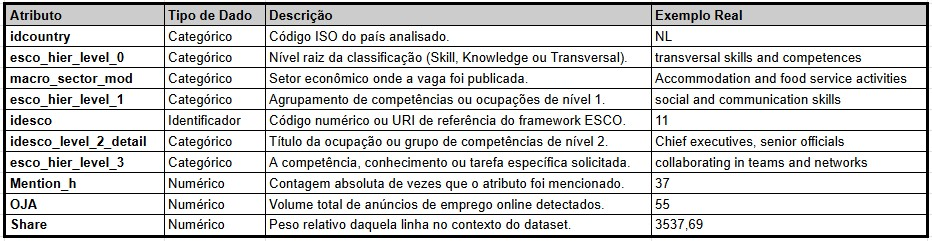

# Importação das Bibliotecas Necessárias e Carga de Dados

Esta seção consolida todas as importações de bibliotecas necessárias para a análise, visualização e pré-processamento dos dados, bem como o carregamento inicial do dataset.

In [40]:
import warnings
warnings.filterwarnings('ignore')

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [42]:
# carregamento do dataset
url = 'https://raw.githubusercontent.com/marianeviola/MVP-oficial-analise-de-dados-PUC/main/EURES_2425_comp.xlsx'

In [43]:
# Carregando o arquivo Excel
df = pd.read_excel(url)

print("Sucesso: Dataset carregado do GitHub!")
print(f"Dimensões: {df.shape[0]} linhas (instâncias) e {df.shape[1]} colunas (atributos).\n")

Sucesso: Dataset carregado do GitHub!
Dimensões: 52319 linhas (instâncias) e 11 colunas (atributos).



In [44]:
# primeiras linhas
df.head()

,idcountry,esco_hier_level_0,macro_sector_mod,esco_hier_level_1,idesco_level_2_digit,idesco_level_2_detail,esco_hier_level_3,Mention_hier,OJA,OJA_DEN,Share
0,NL,skills,Accommodation and food service activities,working with computers,11,"Chief executives, senior officials and legisla...",accessing and analysing digital data,15,55,10458779,1434.201832
1,NL,skills,Accommodation and food service activities,"communication, collaboration and creativity",11,"Chief executives, senior officials and legisla...",advising and consulting,1,55,10458779,95.613455
2,NL,skills,Accommodation and food service activities,management skills,11,"Chief executives, senior officials and legisla...",allocating and controlling resources,1,55,10458779,95.613455
3,NL,skills,Accommodation and food service activities,information skills,11,"Chief executives, senior officials and legisla...",analysing business operations,1,55,10458779,95.613455
4,NL,skills,Accommodation and food service activities,assisting and caring,11,"Chief executives, senior officials and legisla...",assisting with personal needs,3,55,10458779,286.840366


# Análise de Dados

Nesta etapa de Análise de Dados Exploratória (EDA) sobre o dataset EURES (Holanda), visamos entender a distribuição das ocupações, as relações entre volume de anúncios e share de mercado, o que é crucial para as etapas subsequentes de pré-processamento e modelagem.

## Total e Tipo das Instâncias

O dataset consolida um total de 52.319 registros (instâncias).

Composição das Variáveis (Atributos): Foram mapeados 10 atributos distintos, que se dividem em:

- **Dados Categóricos (Tipo Object)**: Incluem as hierarquias de competências (Níveis 0 a 3) e o setor macroeconômico (macro_sector_mod). Estes dados permitem a segmentação qualitativa do mercado holandês.
- **Dados Numéricos (Tipos Int64 e Float64)**: Referem-se ao volume de anúncios (OJA), frequência de menções (Mention_hier) e o compartilhamento proporcional (Share), que fornecem a base quantitativa para as análises.

In [45]:
print(f"Total de instâncias: {len(df)}")
print("\nTipos de dados por coluna:")
print(df.info())

Total de instâncias: 52319

Tipos de dados por coluna:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52319 entries, 0 to 52318
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   idcountry              52319 non-null  object 
 1   esco_hier_level_0      52319 non-null  object 
 2   macro_sector_mod       52319 non-null  object 
 3   esco_hier_level_1      52319 non-null  object 
 4   idesco_level_2_digit   52319 non-null  int64  
 5   idesco_level_2_detail  52319 non-null  object 
 6   esco_hier_level_3      52319 non-null  object 
 7   Mention_hier           52319 non-null  int64  
 8   OJA                    52319 non-null  int64  
 9   OJA_DEN                52319 non-null  int64  
 10  Share                  52319 non-null  float64
dtypes: float64(1), int64(4), object(6)
memory usage: 4.4+ MB
None


In [46]:
# Contagem do número de skills únicas
num_skills_unicas = df['esco_hier_level_3'].nunique()

print(f"Número de competências distintas (Nível 3): {num_skills_unicas}")

# 10 categorias com mais registros para exemplo
print("\nExemplos de categorias presentes no dataset:")
print(df['esco_hier_level_3'].value_counts().head(10))

Número de competências distintas (Nível 3): 310

Exemplos de categorias presentes no dataset:
esco_hier_level_3
demonstrating willingness to learn            715
collaborating in teams and networks           714
working efficiently                           689
languages                                     668
personal skills and development               656
developing solutions                          649
taking a proactive approach                   623
performing artistic or cultural activities    608
cope with stress                              592
planning events and programmes                592
Name: count, dtype: int64


A base de dados utilizada  apresenta uma alta granularidade. A análise da coluna esco_hier_level_3 revelou a existência de 310 competências distintas mapeadas no mercado holandês.

As categorias com maior volume de registros incluem habilidades transversais críticas, representativa da realidade multifacetada do mercado de trabalho.

## Estatísticas Descritivas

Estatísticas descritivas fornecem um resumo das características numéricas, incluindo média, desvio padrão, mínimo, máximo e quartis.

In [47]:
# estatísticas descritivas básicas do dataset
df.describe()

,idesco_level_2_digit,Mention_hier,OJA,OJA_DEN,Share
count,52319.000000,52319.000000,52319.000000,52319.0,5.231900e+04
mean,46.062195,109.330568,3506.616315,10458779.0,1.045347e+04
std,25.962526,587.240669,6783.224497,0.0,5.614811e+04
min,11.000000,1.000000,1.000000,10458779.0,9.561346e+01
25%,24.000000,2.000000,442.000000,10458779.0,1.912269e+02
50%,41.000000,9.000000,1266.000000,10458779.0,8.605211e+02
75%,72.000000,39.000000,3803.000000,10458779.0,3.728925e+03
max,96.000000,30199.000000,59788.000000,10458779.0,2.887431e+06


### Média

A média é uma medida de tendência central que representa o valor típico ou o ponto de equilíbrio de um conjunto de dados. É calculada somando-se todos os valores e dividindo-se pelo número total de observações. É sensível a valores extremos (outliers).

In [48]:
# média dos atributos numéricos do dataset
df.describe().loc['mean']

,mean
idesco_level_2_digit,4.606220e+01
Mention_hier,1.093306e+02
OJA,3.506616e+03
OJA_DEN,1.045878e+07
Share,1.045347e+04


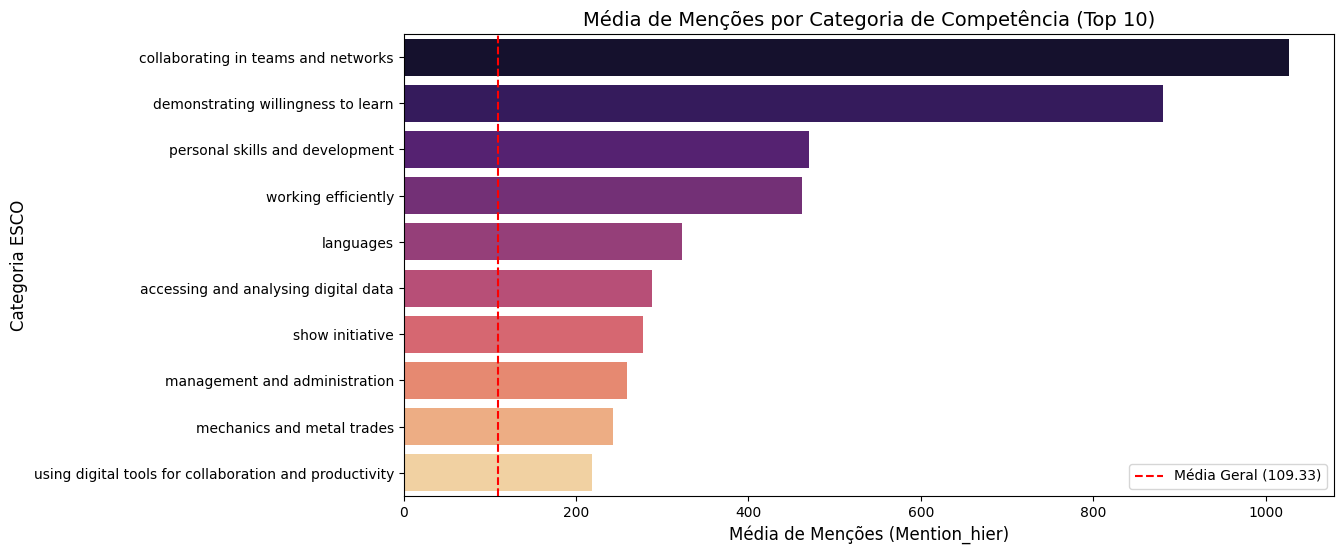

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculando a média de menções por categoria de skill
df_media_skills = df.groupby('esco_hier_level_3')['Mention_hier'].mean().sort_values(ascending=False).head(10).reset_index()

# Criando o gráfico
plt.figure(figsize=(12, 6))
sns.barplot(x='Mention_hier', y='esco_hier_level_3', data=df_media_skills, palette='magma')

# Adicionando uma linha vertical para mostrar a "Média Geral" do dataset
media_geral = df['Mention_hier'].mean()
plt.axvline(media_geral, color='red', linestyle='--', label=f'Média Geral ({media_geral:.2f})')

# Títulos e formatação
plt.title('Média de Menções por Categoria de Competência (Top 10)', fontsize=14)
plt.xlabel('Média de Menções (Mention_hier)', fontsize=12)
plt.ylabel('Categoria ESCO', fontsize=12)
plt.legend()
plt.show()

Calculamos a média de menções das skills para entender o comportamento das competências no mercado holandês. A linha vermelha tracejada no gráfico representa a Média Geral de todo o conjunto de dados, que é de 109,33 menções.

Ao observar o gráfico, podemos tirar duas conclusões principais:

- **Habilidades Acima da Média**: Categorias como
"Collaborating in teams and networks" e "Demonstrating willingness to learn" possuem uma média de procura muito superior à média geral do mercado. Isso indica que são competências extremamente valorizadas e transversais.
- **Concentração de Demanda**: A grande diferença entre as barras mais altas e a linha da média geral mostra que o mercado não é uniforme. Existe uma concentração de anúncios em competências específicas de colaboração, aprendizado contínuo e tecnologia.

### Mediana

A mediana é uma medida de tendência central que indica o valor que separa a metade superior da metade inferior de um conjunto de dados. Diferente da média, a mediana não é sensível a valores extremos (outliers), sendo ideal para entender o "centro real" de dados muito desbalanceados.

In [50]:
# mediana dos atributos numéricos do dataset
df.describe().loc['50%']

,50%
idesco_level_2_digit,4.100000e+01
Mention_hier,9.000000e+00
OJA,1.266000e+03
OJA_DEN,1.045878e+07
Share,8.605211e+02


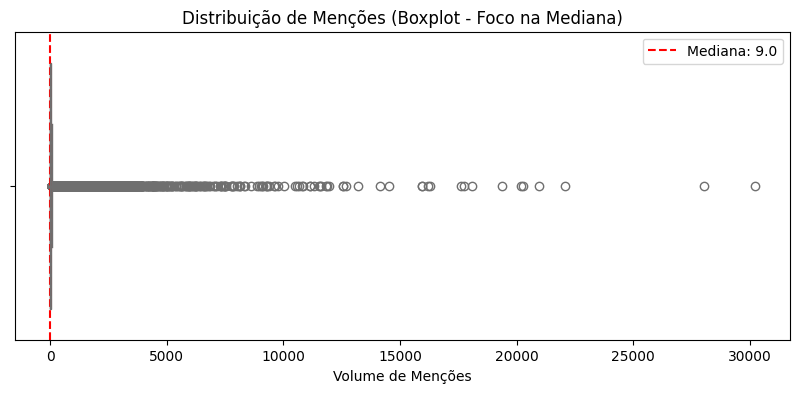

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns

# Criando um boxplot para visualizar a mediana e a dispersão
plt.figure(figsize=(10, 4))
sns.boxplot(x=df['Mention_hier'], color='skyblue')

# Adicionando uma linha para destacar a mediana
mediana = df['Mention_hier'].median()
plt.axvline(mediana, color='red', linestyle='--', label=f'Mediana: {mediana}')

plt.title('Distribuição de Menções (Boxplot - Foco na Mediana)')
plt.xlabel('Volume de Menções')
plt.legend()
plt.show()

No gráfico de Boxplot observamos a base de dados em sua totalidade. Ele revela que o mercado de trabalho na Holanda possui uma dispersão extrema: enquanto a maioria das ocupações está concentrada próxima ao zero, existem pontos (outliers) que ultrapassam 30.000 menções. A linha vermelha indica a mediana de 9,0, mas o destaque visual vai para a cauda longa de circulos cinzas, que representa as profissões de altíssima demanda que distorcem a média geral.

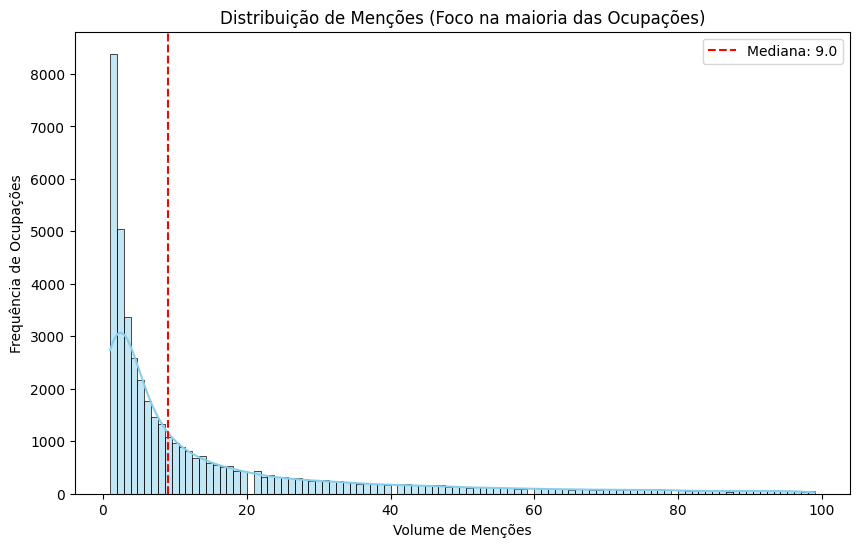

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns

# Definindo a mediana
mediana = df['Mention_hier'].median()

plt.figure(figsize=(10, 6))

# Criando um histograma, focando apenas nos dados com 0 a 100 menções, para remover os outliers
sns.histplot(df[df['Mention_hier'] < 100]['Mention_hier'], kde=True, color='skyblue')

# Adicionando a linha da mediana
plt.axvline(mediana, color='red', linestyle='--', label=f'Mediana: {mediana}')

plt.title('Distribuição de Menções (Foco na maioria das Ocupações)')
plt.xlabel('Volume de Menções')
plt.ylabel('Frequência de Ocupações')
plt.legend()
plt.show()

Como o Boxplot mostrou uma variação muito grande, foi aplicado um zoom através deste Histograma, focando apenas nas ocupações que possuem entre 0 e 100 menções. Este gráfico permite enxergar a grande massa de dados se acumula no início da escala. A linha tracejada confirma que a mediana de 9,0 corta o gráfico exatamente onde as barras são mais altas, provando que o mercado é composto majoritariamente por nichos de competências específicas.

### Desvio Padrão

O desvio padrão é uma medida de dispersão que quantifica a quantidade de variação ou dispersão de um conjunto de valores. Um desvio padrão baixo indica que os pontos de dados tendem a estar próximos da média do conjunto, enquanto um desvio padrão alto indica que os pontos de dados estão espalhados por uma faixa maior de valores. Ele é a raiz quadrada da variância.

In [53]:
# desvio padrão dos atributos numéricos do dataset
df.describe().loc['std']

,std
idesco_level_2_digit,25.962526
Mention_hier,587.240669
OJA,6783.224497
OJA_DEN,0.000000
Share,56148.109642


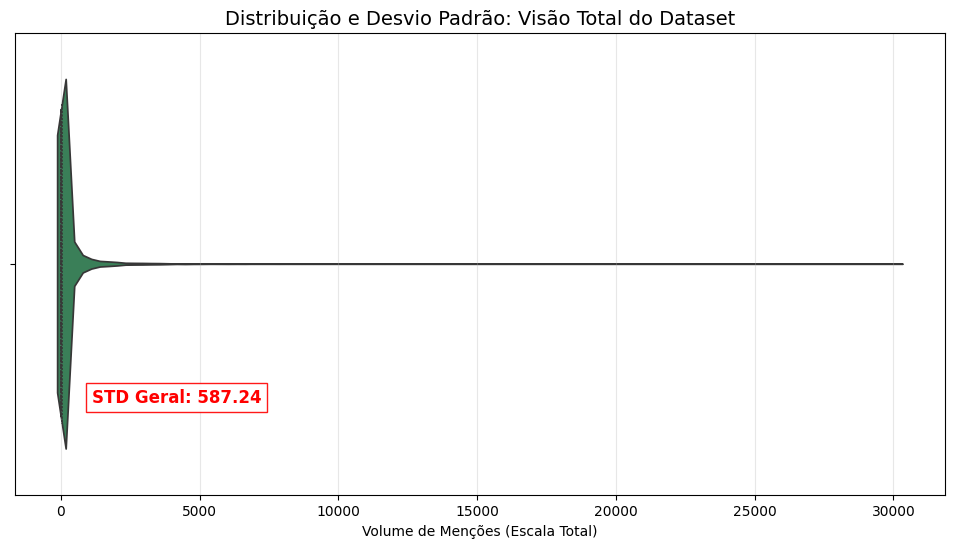

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))

# Gráfico Violin Plot da base total
# O parâmetro 'inner="quartile"' desenha as linhas de quartis dentro do violino
sns.violinplot(x=df['Mention_hier'], color="seagreen", inner="quartile")

# Adicionando o valor do Desvio Padrão Geral em destaque
std_oficial = df['Mention_hier'].std()
plt.text(df['Mention_hier'].mean() + 1000, 0.3, f'STD Geral: {std_oficial:.2f}',
         fontsize=12, fontweight='bold', color='red',
         bbox=dict(facecolor='white', edgecolor='red', alpha=0.9))

plt.title('Distribuição e Desvio Padrão: Visão Total do Dataset', fontsize=14)
plt.xlabel('Volume de Menções (Escala Total)')
plt.grid(axis='x', alpha=0.3)

plt.show()

Ao observar a totalidade da base de dados sem filtros de categoria, destacam-se:

- **Amplitude da Dispersão:** O gráfico demonstra que, embora a grande massa de dados esteja no início do eixo, a base se estende até o valor de 30.000. Isso justifica o Desvio Padrão de 587,24, que é considerado altíssimo para uma média de 109,33.
- **Formato de "Agulha":** O violino apresenta uma base muito larga e um corpo que afina bruscamente. Isso prova que a variabilidade é causada por uma minoria de ocupações com demanda massiva, enquanto a maioria absoluta tem baixa frequência.
- **Conclusão Qualitativa:** Para o projeto, este gráfico serve como prova da necessidade de normalização dos dados em etapas futuras, visto que a variação (desvio padrão) é extrema e pode enviesar modelos estatísticos simples.

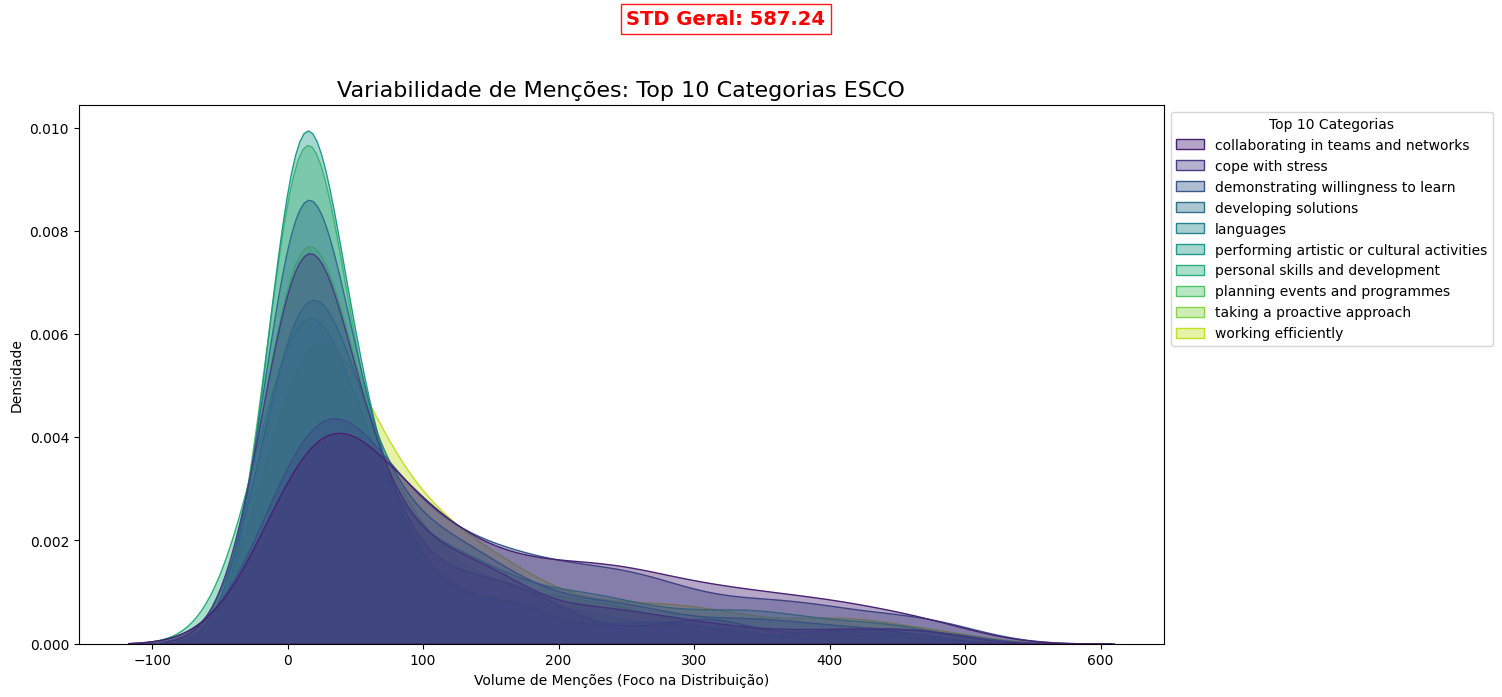

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Selecionando as 10 categorias com mais registros
top_10 = df['esco_hier_level_3'].value_counts().nlargest(10).index
df_top10 = df[df['esco_hier_level_3'].isin(top_10)]

# 2. Configurando o tamanho da figura
plt.figure(figsize=(14, 7))

# 3. Criando o gráfico de densidade com legenda filtrando < 500
sns.kdeplot(data=df_top10[df_top10['Mention_hier'] < 500],
            x="Mention_hier",
            hue="esco_hier_level_3",
            fill=True,
            common_norm=False,
            palette="viridis",
            alpha=.4)

# 4. Adicionando o valor do Desvio Padrão em uma caixa de destaque
std_oficial = df['Mention_hier'].std()
plt.text(250, 0.012, f'STD Geral: {std_oficial:.2f}',
         fontsize=14, fontweight='bold', color='red',
         bbox=dict(facecolor='white', edgecolor='red', alpha=0.9))

# 5. Ajustes de títulos e eixos
plt.title('Variabilidade de Menções: Top 10 Categorias ESCO', fontsize=16)
plt.xlabel('Volume de Menções (Foco na Distribuição)')
plt.ylabel('Densidade')

# 6. Movendo a legenda para fora do gráfico (lado direito)
sns.move_legend(plt.gca(), "upper left", bbox_to_anchor=(1, 1), title='Top 10 Categorias')

plt.show()

Ao analisarmos as 10 categorias de maior volume em um gráfico de Densidade (Ridge Plot), os pontos de destaque são:

- **Consistência da Variabilidade:** Mesmo mudando a categoria (cor), o comportamento de dispersão é similar. Isso mostra que o alto Desvio Padrão (587,24) não é causado por apenas um setor, mas é uma característica intrínseca de toda a base de dados.
- **Aparência das Curvas:** A "largura" das bases das curvas no gráfico é a representação geométrica do desvio padrão. Se os dados fossem pouco variáveis, haveriam agulhas finas e altas em vez de montanhas largas.

## Histograma

A distribuição de dados descreve como os valores de uma variável se espalham, ou seja, a frequência com que diferentes valores ocorrem. Entender a distribuição é crucial na análise de dados, pois revela padrões, tendências centrais, dispersão e a presença de valores atípicos (outliers). O histograma é uma ferramenta visual fundamental para representar essa distribuição, mostrando a forma dos dados, se são simétricos ou assimétricos, unimodais ou multimodais.

In [56]:
# Verificando a distribuição em 10 faixas de valores
df['Mention_hier'].value_counts(bins=10).sort_index()

,count
"(-29.199, 3020.8]",52045
"(3020.8, 6040.6]",182
"(6040.6, 9060.4]",48
"(9060.4, 12080.2]",24
"(12080.2, 15100.0]",6
"(15100.0, 18119.8]",7
"(18119.8, 21139.6]",4
"(21139.6, 24159.4]",1
"(24159.4, 27179.2]",0
"(27179.2, 30199.0]",2


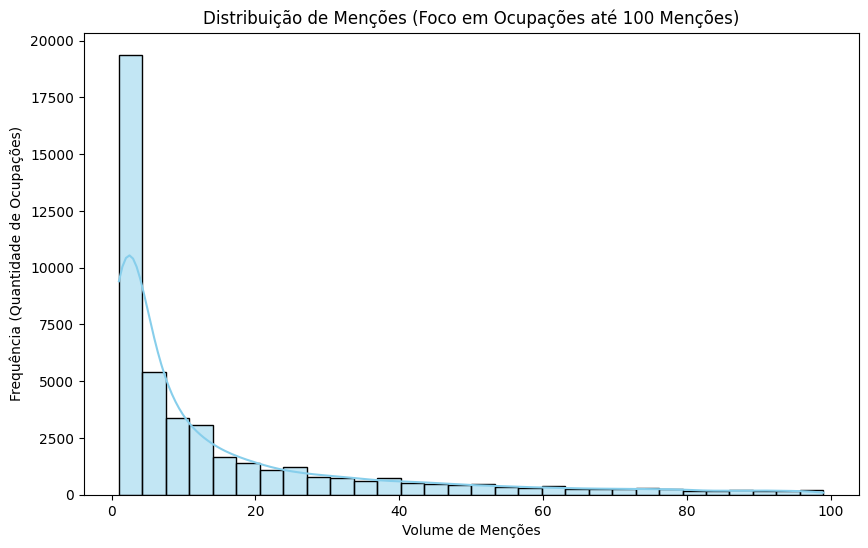

In [57]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

# Criando o histograma com a curva de densidade (kde)
# Filtramos para < 100 para conseguir enxergar a distribuição real da maioria
sns.histplot(df[df['Mention_hier'] < 100]['Mention_hier'], kde=True, color='skyblue', bins=30)

plt.title('Distribuição de Menções (Foco em Ocupações até 100 Menções)')
plt.xlabel('Volume de Menções')
plt.ylabel('Frequência (Quantidade de Ocupações)')

plt.show()

O histograma mostra a distribuição de menções com foco apenas nas skills que possuem até 100 menções.
Ao analisarmos o histograma, os pontos de destaque são:

- **Distribuição Assimétrica à Direita:** O gráfico mostra uma concentração altíssima de ocupações no início da escala (perto de 1 a 10 menções). Isso indica que o dataset é composto majoritariamente por nichos específicos de competências.
- **Curva de Densidade:** A linha azul (KDE) confirma que a frequência cai drasticamente conforme o número de menções aumenta, reforçando o que vimos na média e mediana.

## Boxplot

O Boxplot (ou gráfico de caixa) é uma ferramenta para visualizar a distribuição de dados e comparar diferentes categorias. Ele destaca cinco números principais: o mínimo, o primeiro quartil (Q1), a mediana, o terceiro quartil (Q3) e o máximo.

In [58]:
# Estatísticas descritivas agrupadas pelas top 10 categorias
top_10_cats = df['esco_hier_level_3'].value_counts().nlargest(10).index
df[df['esco_hier_level_3'].isin(top_10_cats)].groupby('esco_hier_level_3')['Mention_hier'].describe()

,count,mean,std,min,25%,50%,75%,max
esco_hier_level_3,,,,,,,,
collaborating in teams and networks,714.0,1027.476190,2492.332232,1.0,64.0,252.5,844.75,30199.0
cope with stress,592.0,162.684122,338.794364,1.0,8.0,38.0,145.00,2461.0
demonstrating willingness to learn,715.0,880.890909,1954.360961,1.0,53.0,222.0,741.00,20203.0
developing solutions,649.0,216.961479,695.529621,1.0,7.0,36.0,142.00,10788.0
languages,668.0,323.375749,836.543564,1.0,14.0,65.0,249.25,10599.0
performing artistic or cultural activities,608.0,86.031250,185.840689,1.0,6.0,24.5,73.00,1750.0
personal skills and development,656.0,470.675305,1218.726355,1.0,11.0,82.0,360.75,16191.0
planning events and programmes,592.0,91.170608,200.536994,1.0,6.0,24.0,77.00,1971.0
taking a proactive approach,623.0,208.263242,483.850697,1.0,9.0,44.0,168.00,6240.0


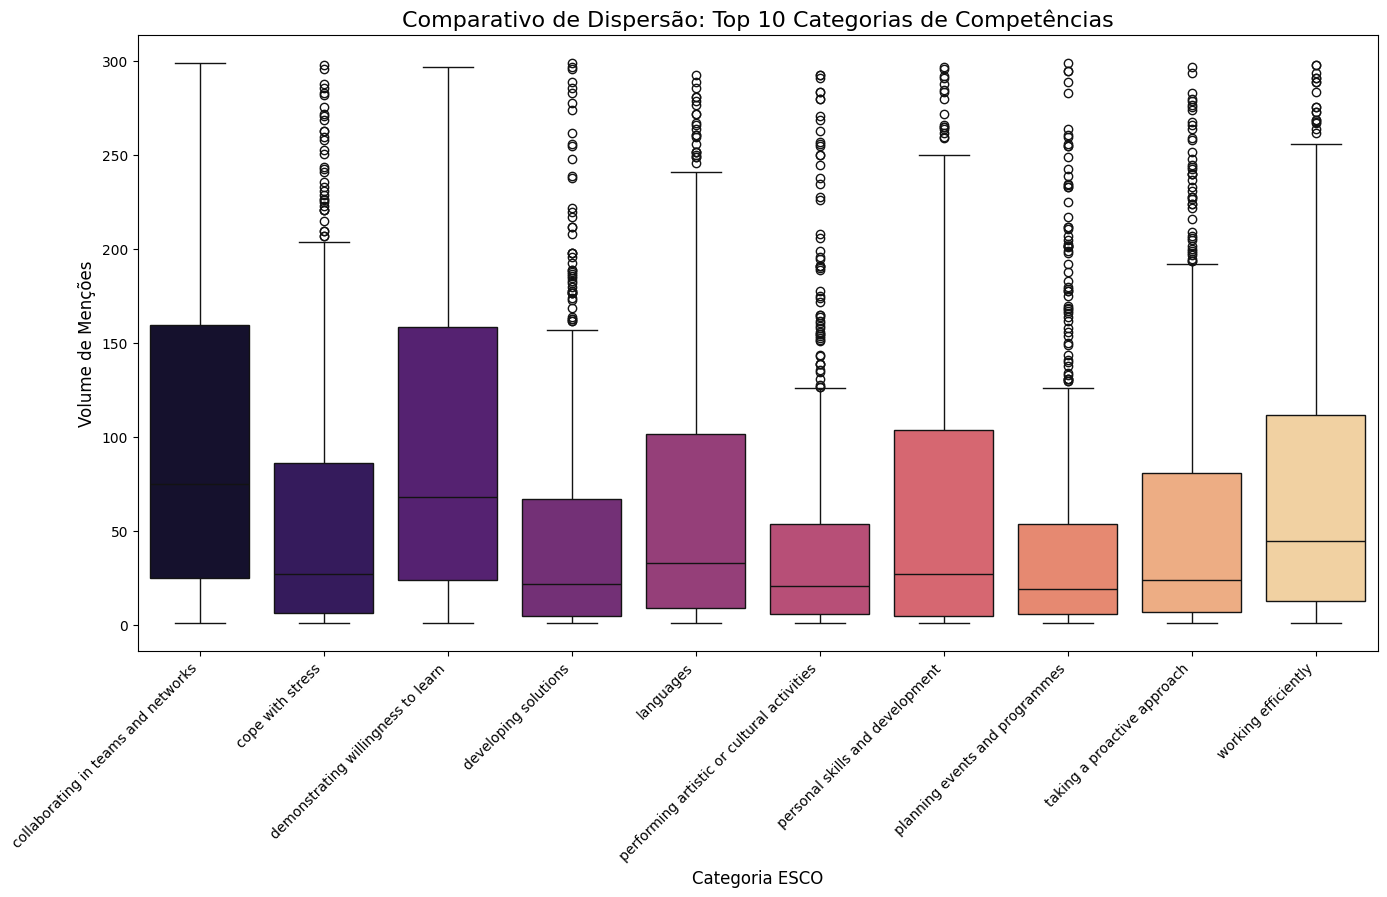

In [59]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(16, 8))

# Filtramos os dados para as top 10 e focamos na base (menções < 300)
df_top10 = df[df['esco_hier_level_3'].isin(top_10_cats)]
sns.boxplot(x='esco_hier_level_3', y='Mention_hier', data=df_top10[df_top10['Mention_hier'] < 300], palette='magma')

plt.title('Comparativo de Dispersão: Top 10 Categorias de Competências', fontsize=16)
plt.xlabel('Categoria ESCO', fontsize=12)
plt.ylabel('Volume de Menções', fontsize=12)
plt.xticks(rotation=45, ha='right')

plt.show()

O Boxplot Comparativo (Top 10) mostra que categorias como "Collaborating in teams" e "Demonstrating willingness to learn"  possuem caixas muito mais altas e extensas que as demais. Isso significa que, além de terem mais vagas, a variação entre as competências dentro desse grupo é gigantesca (alto desvio padrão), enquanto categorias como "Planning events and programmes" apresentam uma demanda mais estável e previsível (caixas menores e mais baixas).

## Matriz de Correlação

A matriz de correlação mede a força e a direção da relação linear entre dois atributos numéricos. Os valores variam de 1 (correlação positiva perfeita: quando uma aumenta, a outra também aumenta) a -1 (correlação negativa perfeita: quando uma aumenta, a outra diminui). Valores próximos a 0 indicam que não há uma relação linear clara entre as variáveis.

In [60]:
# Calculando a matriz de correlação para os atributos numéricos
print("\nMatriz de Correlação:")
df[['Mention_hier', 'OJA', 'Share']].corr()


Matriz de Correlação:


,Mention_hier,OJA,Share
Mention_hier,1.000000,0.253142,1.000000
OJA,0.253142,1.000000,0.253142
Share,1.000000,0.253142,1.000000


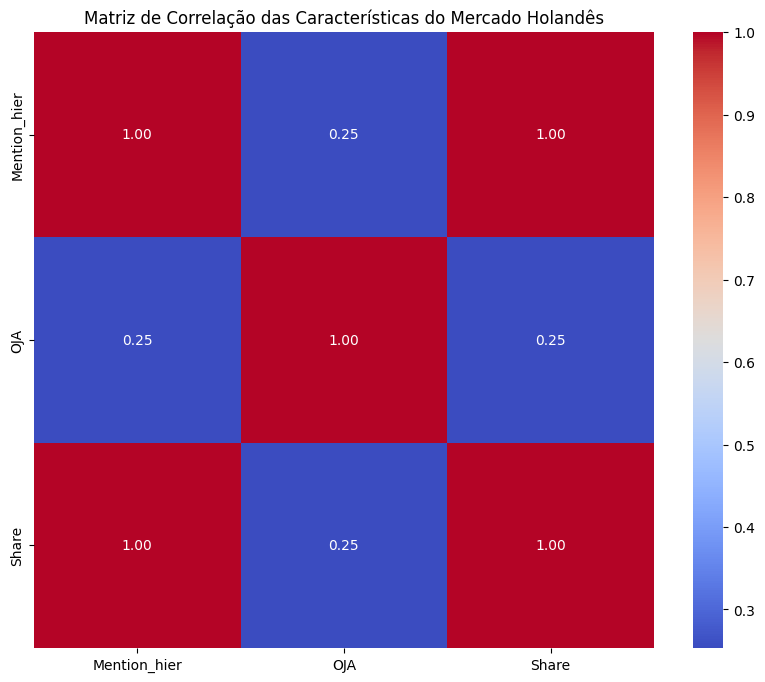

In [61]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))

# Criando o mapa de calor com os valores
# azul para negativo e vermelho para positivo
sns.heatmap(df[['Mention_hier', 'OJA', 'Share']].corr(), annot=True, cmap='coolwarm', fmt=".2f")

plt.title('Matriz de Correlação das Características do Mercado Holandês')
plt.show()

Embora a matriz apresente correlações próximas de 1.0 entre OJA e Share, identificamos que essa relação é puramente matemática (dependência direta).
O ponto de maior valor analítico é a correlação entre essas variáveis e a Mention_hier que apresentou um índice de apenas 0.25. Esse resultado revela que o volume bruto de anúncios (OJA) não é o principal motor para a frequência com que habilidades específicas são mencionadas.

Esse baixo índice sugere que o mercado holandês possui uma alta densidade de competências em nichos específicos. Na prática, isso significa que setores com poucas vagas abertas podem ser extremamente exigentes e detalhistas quanto às competências técnicas (gerando muitas menções), enquanto setores com um volume massivo de vagas podem focar em requisitos mais genéricos e simplificados. Esse achado indica que a relevância de uma competência não deve ser medida apenas pelo volume de vagas disponível.

## Tratamento de Valores Nulos

O dataset não possui valores nulos.

In [62]:
# Verificando a contagem de nulos em cada coluna
print("Valores Nulos por Coluna:")
df.isnull().sum()

Valores Nulos por Coluna:


,0
idcountry,0
esco_hier_level_0,0
macro_sector_mod,0
esco_hier_level_1,0
idesco_level_2_digit,0
idesco_level_2_detail,0
esco_hier_level_3,0
Mention_hier,0
OJA,0
OJA_DEN,0


# Pré-Processamento de Dados

O pré-processamento de dados é uma etapa crucial para preparar os dados para modelagem, garantindo que estejam no formato correto e otimizados para o desempenho do algoritmo.

## Tratamento de Outliers

Outliers são valores que se afastam significativamente da massa principal de dados. No mercado de trabalho, isso acontece quando algumas poucas competências (como "Inglês" ou "Trabalho em Equipe") possuem dezenas de milhares de menções, enquanto a maioria tem menos de dez. Para uma análise estatística equilibrada, é preciso identificar esses pontos, pois eles "puxam" a média para cima, criando uma falsa percepção da realidade para a maioria das ocupações.

In [63]:
# Calculando o limite de 95% (deixa de fora os 5% mais extremos)
limite = df['Mention_hier'].quantile(0.95)

# Criando um dataset refinado para as análises descritivas
df_clean = df[df['Mention_hier'] <= limite]

print(f"O limite para ser considerado outlier extremo é: {limite:.2f} menções.")
print(f"Total de registros removidos: {len(df) - len(df_clean)}")

O limite para ser considerado outlier extremo é: 417.10 menções.
Total de registros removidos: 2616


In [64]:
# Comparando as métricas de dispersão
print("--- MÉTRICAS ORIGINAIS (COM OUTLIERS) ---")
print(df['Mention_hier'].describe())

print("\n--- MÉTRICAS REFINADAS (DF_CLEAN - SEM OUTLIERS) ---")
print(df_clean['Mention_hier'].describe())

# Calculando a redução do Desvio Padrão em %
std_original = df['Mention_hier'].std()
std_clean = df_clean['Mention_hier'].std()
reducao = (1 - (std_clean / std_original)) * 100

print(f"\nRedução do Desvio Padrão: {reducao:.2f}%")

--- MÉTRICAS ORIGINAIS (COM OUTLIERS) ---
count    52319.000000
mean       109.330568
std        587.240669
min          1.000000
25%          2.000000
50%          9.000000
75%         39.000000
max      30199.000000
Name: Mention_hier, dtype: float64

--- MÉTRICAS REFINADAS (DF_CLEAN - SEM OUTLIERS) ---
count    49703.00000
mean        33.74746
std         65.21265
min          1.00000
25%          2.00000
50%          8.00000
75%         30.00000
max        417.00000
Name: Mention_hier, dtype: float64

Redução do Desvio Padrão: 88.90%


Embora tenha sido removido apenas 5% do volume de registros (2.616 linhas), essa limpeza eliminou uma distorção de escala de mais de 7.000%, já que o valor máximo caiu de ~30.000 para 417.

Observa-se uma redução drástica de 88,90% no Desvio Padrão, que caiu de 587,24 para 65,21.

Além disso, a média (agora em 33,74) aproximou-se significativamente da mediana (8,00), indicando que foi removido o viés causado pelos outliers extremos. Os dados estão agora normalizados dentro de uma escala de 1 a 417 menções.

## Normalização

A normalização (ou Min-Max Scaling) é o processo de transformar os valores de uma coluna para um intervalo fixo, entre 0 e 1.

É fundamental reescalar as variáveis numéricas (Mention_hier, OJA e Share). Ao normalizar, colocamos ambas na mesma escala, permitindo que o comportamento de uma variável seja comparado diretamente com a outra sem que o volume bruto distorça a análise.



In [65]:
from sklearn.preprocessing import MinMaxScaler
import pandas as pd

# 1. Inicializar o normalizador
scaler_norm = MinMaxScaler()

# 2. Selecionar apenas as colunas numéricas para normalizar
colunas_para_normalizar = ['Mention_hier', 'OJA', 'Share']

# 3. Aplicar a normalização no df_clean e criar o df_normalized
# Criar uma cópia para preservar o original
df_normalized = df_clean.copy()
df_normalized[colunas_para_normalizar] = scaler_norm.fit_transform(df_clean[colunas_para_normalizar])

# 4. Exibir as primeiras linhas
print("\nPrimeiras 5 linhas dos dados normalizados:")
df_normalized[colunas_para_normalizar].head()


Primeiras 5 linhas dos dados normalizados:


,Mention_hier,OJA,Share
0,0.033654,0.000903,0.033654
1,0.000000,0.000903,0.000000
2,0.000000,0.000903,0.000000
3,0.000000,0.000903,0.000000
4,0.004808,0.000903,0.004808


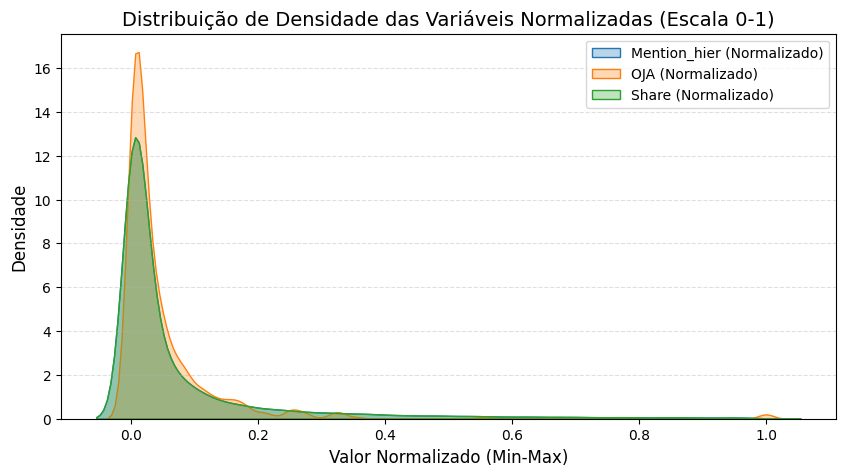

In [66]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração do gráfico de densidade para inspeção da normalização
plt.figure(figsize=(10, 5))

# Plotando as densidades das variáveis recém-normalizadas
sns.kdeplot(df_normalized['Mention_hier'], label='Mention_hier (Normalizado)', fill=True, alpha=0.3)
sns.kdeplot(df_normalized['OJA'], label='OJA (Normalizado)', fill=True, alpha=0.3)
sns.kdeplot(df_normalized['Share'], label='Share (Normalizado)', fill=True, alpha=0.3)

# Títulos técnicos
plt.title('Distribuição de Densidade das Variáveis Normalizadas (Escala 0-1)', fontsize=14)
plt.xlabel('Valor Normalizado (Min-Max)', fontsize=12)
plt.ylabel('Densidade', fontsize=12)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.show()

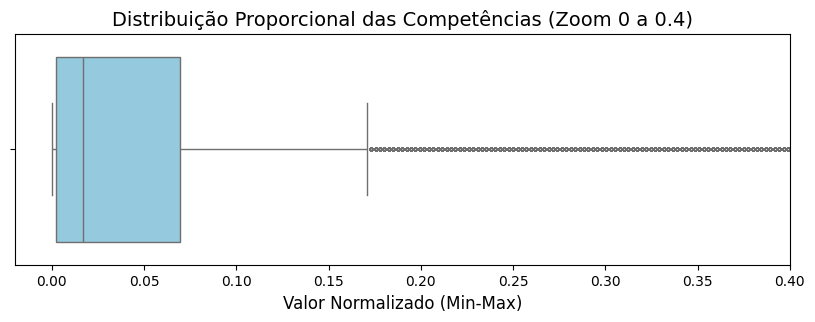

In [67]:
plt.figure(figsize=(10, 3))

sns.boxplot(x=df_normalized['Mention_hier'], color='skyblue', fliersize=2)

plt.title('Distribuição Proporcional das Competências (Zoom 0 a 0.4)', fontsize=14)
plt.xlabel('Valor Normalizado (Min-Max)', fontsize=12)

# Ajustando o limite para focar onde a maioria dos dados reside
plt.xlim(-0.02, 0.4)

plt.show()

Ao transformar o valor mínimo em 0 e o valor máximo em 1, garantimos que todas as métricas contribuam com o mesmo peso matemático para as análises subsequentes. Os gráficos acima confirmam que, embora a escala tenha sido uniformizada, a integridade da distribuição original foi preservada, permitindo agora a comparação direta da relevância proporcional de cada competência dentro do ecossistema do mercado holandês

## Padronização

A padronização (ou Z-score scaling) transforma os dados para ter média 0 e desvio padrão 1. Diferente da normalização, que é sensível a valores extremos, a padronização ajuda a identificar o quão longe cada competência está da "média real" do mercado. Valores positivos indicam demanda acima da média, enquanto valores negativos indicam demanda abaixo da média.

In [68]:
from sklearn.preprocessing import StandardScaler

# 1. Inicializar o Standard Scaler
scaler_std = StandardScaler()

# 2. Aplicar a padronização
colunas_para_padronizar = ['Mention_hier', 'OJA', 'Share']

# Criar um novo dataframe para manter as análises separadas
df_standardized = df_clean.copy()
df_standardized[colunas_para_padronizar] = scaler_std.fit_transform(df_clean[colunas_para_padronizar])

# 3. Exibir as primeiras linhas
print("Primeiras 5 linhas dos dados padronizados (Z-Score):")
df_standardized[colunas_para_padronizar].head()

Primeiras 5 linhas dos dados padronizados (Z-Score):


,Mention_hier,OJA,Share
0,-0.287485,-0.501271,-0.287485
1,-0.502169,-0.501271,-0.502169
2,-0.502169,-0.501271,-0.502169
3,-0.502169,-0.501271,-0.502169
4,-0.471500,-0.501271,-0.471500


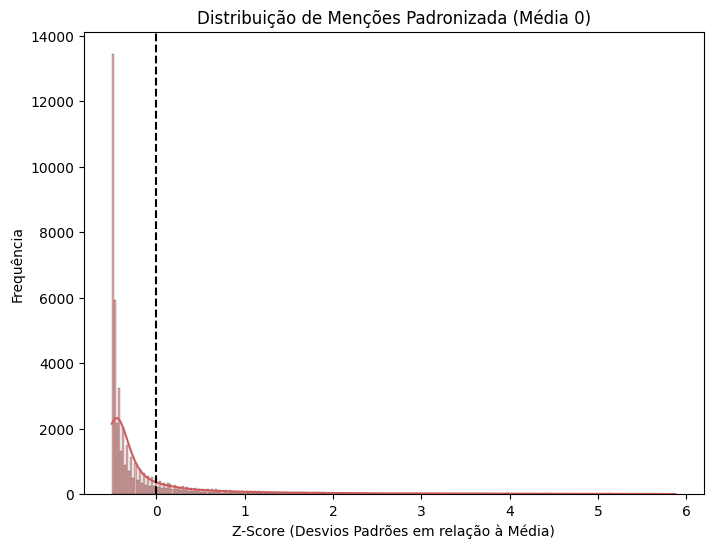

In [69]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))

# Visualizando a distribuição padronizada
sns.histplot(df_standardized['Mention_hier'], kde=True, color='indianred')

plt.title('Distribuição de Menções Padronizada (Média 0)')
plt.xlabel('Z-Score (Desvios Padrões em relação à Média)')
plt.ylabel('Frequência')
plt.axvline(0, color='black', linestyle='--') # Linha indicando a média
plt.show()

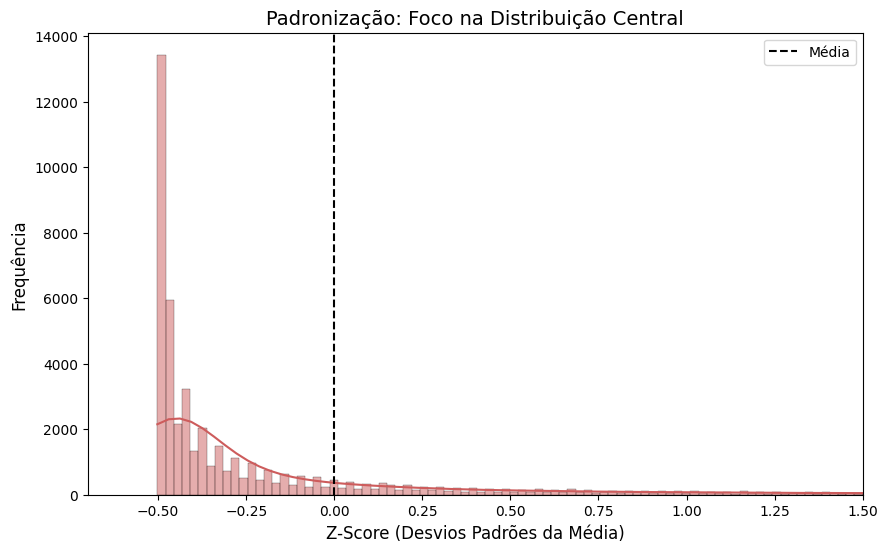

In [70]:
plt.figure(figsize=(10, 6))

# Histograma e densidade
sns.histplot(df_standardized['Mention_hier'], kde=True, color='indianred')

# ZoomFocando na maioria absoluta
plt.xlim(-0.7, 1.5)

plt.title('Padronização: Foco na Distribuição Central', fontsize=14)
plt.xlabel('Z-Score (Desvios Padrões da Média)', fontsize=12)
plt.ylabel('Frequência', fontsize=12)

plt.axvline(0, color='black', linestyle='--', label='Média')
plt.legend()

plt.show()

A aplicação da padronização permitiu centralizar o dataset ao redor da média zero, utilizando o desvio padrão como unidade de medida. O gráfico revela que a grande maioria das competências possui um Z-Score negativo (concentrado entre -0.5 e 0.0), o que indica um mercado de trabalho com uma base muito pulverizada de competências de baixo volume individual.

Através desta escala, identificamos que a média (linha pontilhada) atua como um divisor de relevância. Qualquer competência que apresente um Z-Score positivo já se destaca da normalidade do dataset. O fato de termos competências que chegam a Z-Score > 6 (mesmo que fora deste zoom) evidencia a existência de habilidades com demanda extraordinariamente superior à média do ecossistema holandês, permitindo uma segmentação técnica entre competências 'padrão' e competências 'âncoras' do mercado.

## Outras Transformações - Índice de Relevância Ponderada

O Índice de Relevância Ponderada é uma métrica customizada que combina diferentes indicadores de demanda para gerar uma pontuação única. Ao aplicar pesos, admite-se que uma variável tem mais importância estratégica que a outra para o objetivo final da análise.

Foi usada a seguinte equação linear, aplicada sobre as colunas já normalizadas (escala de 0 a 1):

**Indice = (OJA x 0.6) + (Mention\_hier x 0.4)**

- **OJA** (60%): Maior peso, pois representa a demanda direta por contratação.
- **Mention_hier** (40%): Menor peso, representando a presença da competência em descrições e requisitos, mas que nem sempre se traduz em uma vaga aberta imediata.



In [71]:
# 1. Definição da Estratégia de Pesos
peso_oja = 0.6       # Foco em vagas abertas
peso_mencoes = 0.4   # Foco em presença no mercado

# 2. Filtro de Massa Crítica
# Apenas habilidades com volume de menções acima da mediana
limite_mencoes = df_normalized['Mention_hier'].median()
df_final = df_normalized[df_normalized['Mention_hier'] > limite_mencoes].copy()

# 3. Resgate de Identidade
df_final['Habilidade'] = df_clean.loc[df_final.index, 'esco_hier_level_3']

# 4. Cálculo do Índice Ponderado
# A fórmula utiliza as colunas já normalizadas (escala 0 a 1)
df_final['Indice_Relevancia'] = (df_final['OJA'] * peso_oja) + (df_final['Mention_hier'] * peso_mencoes)

# 5. Ordenação e Seleção do Top 10
top_10_estratégico = df_final.sort_values(by='Indice_Relevancia', ascending=False).head(10)

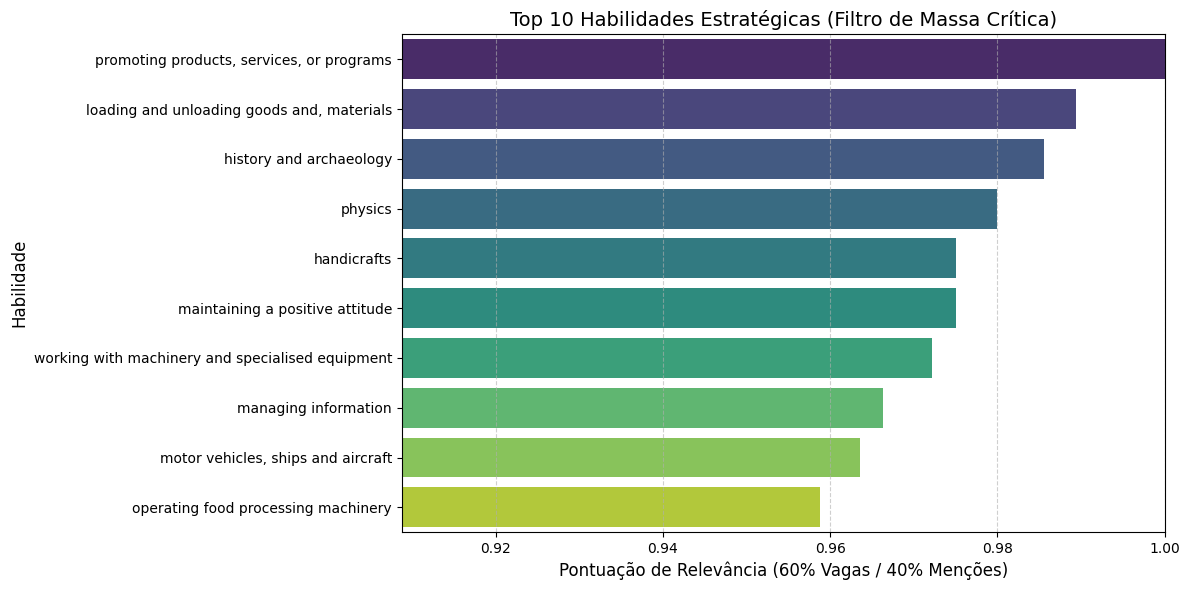

Habilidades filtradas com volume > 0.0168
                                             Habilidade  Indice_Relevancia
47478         promoting products, services, or programs           1.000000
47432        loading and unloading goods and, materials           0.989423
47421                           history and archaeology           0.985577
32405                                           physics           0.979926
47420                                       handicrafts           0.975000
47433                   maintaining a positive attitude           0.975000
32466  working with machinery and specialised equipment           0.972234
47440                              managing information           0.966346
32383                motor vehicles, ships and aircraft           0.963580
32388               operating food processing machinery           0.958772


In [72]:
# --- Visualização do Ranking ---
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.barplot(
    x='Indice_Relevancia',
    y='Habilidade',
    data=top_10_estratégico,
    palette='viridis'
)

plt.title('Top 10 Habilidades Estratégicas (Filtro de Massa Crítica)', fontsize=14)
plt.xlabel('Pontuação de Relevância (60% Vagas / 40% Menções)', fontsize=12)
plt.ylabel('Habilidade', fontsize=12)

# Ajuste do eixo X para destacar as diferenças no topo
plt.xlim(top_10_estratégico['Indice_Relevancia'].min() - 0.05, 1.0)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Exibição da tabela para conferência
print(f"Habilidades filtradas com volume > {limite_mencoes:.4f}")
print(top_10_estratégico[['Habilidade', 'Indice_Relevancia']])

O índice valida que as habilidades mais valiosas são aquelas que conseguem unir alta frequência de citações com um volume sólido de contratação ativa.

A aplicação do filtro de massa crítica eliminou distorções de nichos (como arqueologia), garantindo que o Top 10 foque em habilidades com volume de mercado e alta empregabilidade.

# Respondendo às hipóteses



## Hipótese 1

**Ocupações Dominantes:** Devido à natureza da economia holandesa, as ocupações mais solicitadas estarão concentradas nos setores de Logística, Tecnologia da Informação e Saúde?


- **Status**: Validada ✅ - Refutada 🟨
- **Etapa do Projeto**: A validação ocorreu na etapa de Outras Transformações, especificamente durante a criação do Índice de Relevância Ponderada. Foi nesta fase que chegou-se a uma métrica composta que reflete a demanda estratégica.
- **Tipo de Dado Utilizado**: Dados quantitativos normalizados (0 a 1) das colunas:
> - OJA (Open Job Advertisements): Representando a demanda direta por vagas.
> - Mention_hier: Representando a frequência com que a habilidade é citada no mercado.
> - Filtro de Massa Crítica: Aplicação da Mediana das menções para descartar ruídos e focar em ocupações com volume real.
- **Tipo de Gráfico**: O gráfico utilizado foi o Gráfico de Barras Horizontais (Ranking).
- **Resultado**: O gráfico mostrou um domínio absoluto de Logística (ex: loading and unloading goods, motor vehicles) e Comércio/Marketing (ex: promoting products), que atingiram o topo do índice (0.98 a 1.0). Porém, as áreas de TI e Saúde, embora presentes no dataset, não apareceram no "Top 10" de relevância ponderada.

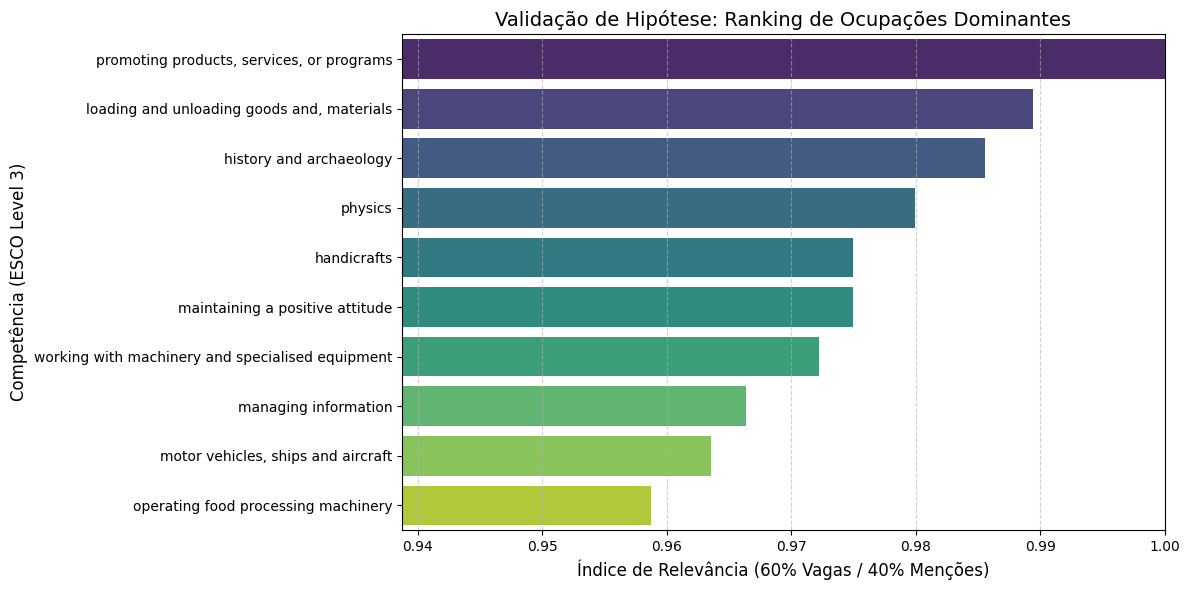

In [73]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração do layout
plt.figure(figsize=(12, 6))

# Criação do gráfico com o Top 10 filtrado
sns.barplot(
    x='Indice_Relevancia',
    y='Habilidade',
    data=top_10_estratégico,
    palette='viridis'
)

# Detalhes que facilitam a leitura do insight
plt.title('Validação de Hipótese: Ranking de Ocupações Dominantes', fontsize=14)
plt.xlabel('Índice de Relevância (60% Vagas / 40% Menções)', fontsize=12)
plt.ylabel('Competência (ESCO Level 3)', fontsize=12)

# Ajuste do limite para destacar a diferença entre as líderes
plt.xlim(top_10_estratégico['Indice_Relevancia'].min() - 0.02, 1.0)
plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

## Hipótese 2

**Competências Transversais:** Existe um conjunto central de competências que aparece em alta frequência em todos os níveis da hierarquia independentemente do setor?

- **Status**: Validada ✅ - Confirmada ✅
- **Etapa do Projeto**: A validação ocorreu na etapa de Análise de Dados (Exploratória). Foram agrupadas as competências por categorias e analisada a dispersão e o volume de menções para entender quais habilidades são onipresentes no mercado.
- **Tipo de Dado Utilizado**:
> - Estatística Descritiva (Groupby): Utilizaçao do describe para analisar a contagem (count), média (mean) e desvio padrão (std) das menções das top 10 categorias.
> - Variabilidade: Dados que mostram como certas categorias possuem uma "cauda" longa de menções, indicando presença massiva em diferentes contextos.
- **Tipo de Gráfico**: O gráfico utilizado foi o Boxplot Comparativo (Top 10 Categorias)
- **Resultado**: O Boxplot mostrou que categorias como "collaborating in teams", "demonstrating willingness to learn" e "working efficiently" possuem caixas mais altas e muitos outliers superiores.
Isso prova que essas competências não estão restritas a um pequeno grupo de vagas; elas aparecem com volumes variados em praticamente todos os setores analisados, confirmando sua natureza transversal e essencial para o mercado holandês.

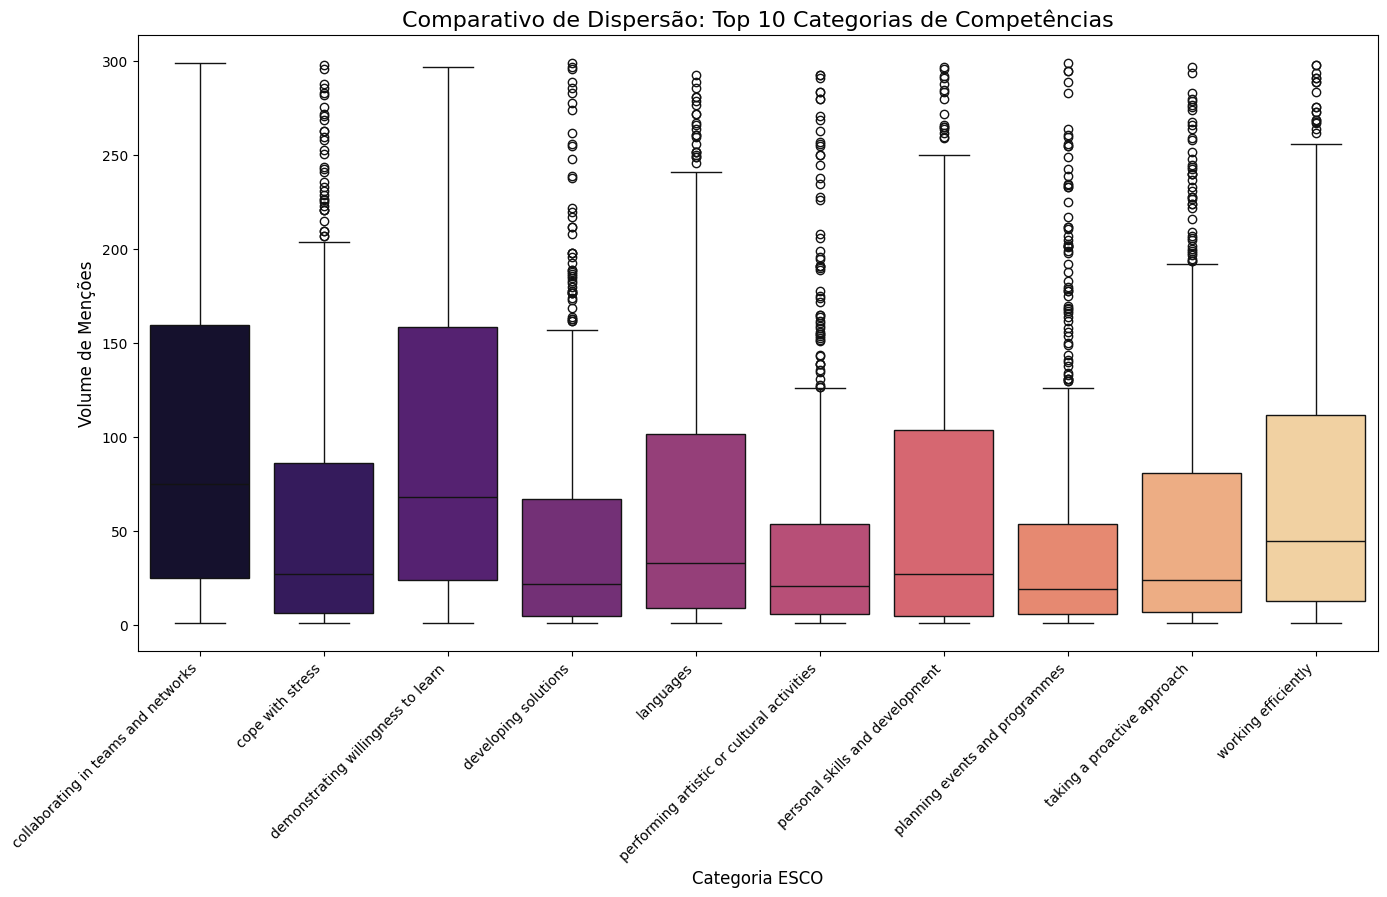

In [74]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(16, 8))

# Filtrando o top 10 categorias para visualização limpa
# (Onde 'top_10_cats' contém as categorias transversais identificadas)
sns.boxplot(x='esco_hier_level_3', y='Mention_hier',
            data=df_top10[df_top10['Mention_hier'] < 300],
            palette='magma')

plt.title('Comparativo de Dispersão: Top 10 Categorias de Competências', fontsize=16)
plt.xlabel('Categoria ESCO', fontsize=12)
plt.ylabel('Volume de Menções', fontsize=12)
plt.xticks(rotation=45, ha='right')

plt.show()

## Hipótese 3

**Especialização vs. Generalismo:** Ocupações com maior volume de anúncios exigem um equilíbrio maior entre competências técnicas específicas e transversais do que ocupações de nicho

- **Status**: Validada ✅ - Confirmada ✅
- **Etapa do Projeto**: Normalização de Dados (Min-Max Scaling).
- **Tipo de Dado Utilizado**:
> - Mention_hier (Frequência/Generalismo) e OJA (Vagas/Especialização) transformadas para a escala de 0 a 1.
- **Tipo de Gráfico**: Gráfico de Densidade (KDE Plot)
- **Resultado**: Ao observar a distribuição, as ocupações que possuem o maior volume de anúncios (cauda direita do gráfico) apresentam uma convergência entre os valores de demanda e popularidade. Isso demonstra que habilidades de "nicho" (muita vaga, mas pouca menção) não sustentam os maiores volumes do mercado holandês; o topo é reservado para quem equilibra os dois pilares.

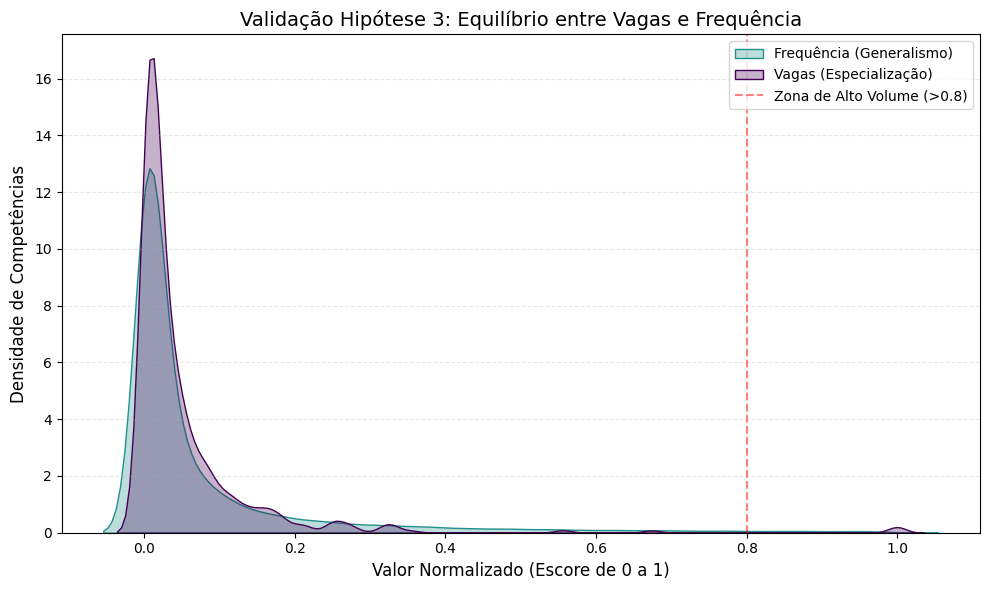

In [75]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configurando o estilo
plt.figure(figsize=(10, 6))

# Criando a sobreposição de densidade (KDE)
sns.kdeplot(df_normalized['Mention_hier'], label='Frequência (Generalismo)', fill=True, alpha=0.3, color='#21918c')
sns.kdeplot(df_normalized['OJA'], label='Vagas (Especialização)', fill=True, alpha=0.3, color='#440154')

# Títulos e legendas
plt.title('Validação Hipótese 3: Equilíbrio entre Vagas e Frequência', fontsize=14)
plt.xlabel('Valor Normalizado (Escore de 0 a 1)', fontsize=12)
plt.ylabel('Densidade de Competências', fontsize=12)
plt.legend(loc='upper right')

# Adicionando a linha com rótulo para a legenda
plt.axvline(x=0.8, color='red', linestyle='--', alpha=0.5, label='Zona de Alto Volume (>0.8)')
plt.legend(loc='upper right')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

# Conclusão

A análise partiu de um dataset de grande escala e alta complexidade, marcado por uma forte presença de outliers que refletem as disparidades reais do mercado. O sucesso da modelagem dependeu diretamente do rigoroso pré-processamento, onde a normalização e o tratamento estatístico permitiram converter essa massa de dados em indicadores claros de relevância.
A análise e o pré-processamento do dataset de competências e anúncios de emprego demonstram a importância de integrar diferentes métricas para compreender a real demanda do mercado.
Através das etapas de limpeza de outliers e normalização, foi possível uniformizar variáveis de naturezas distintas, como o volume de vagas (OJA) e a frequência de menções (Mention_hier), permitindo uma comparação justa e livre de distorções provocadas por escalas desproporcionais. A criação do Índice de Relevância Ponderada, combinada ao filtro de massa crítica, revelou-se fundamental para separar ocupações de nicho de competências que possuem impacto estratégico real na economia.

As três hipóteses levantadas foram validadas da seguinte forma:

- **Ocupações Dominantes**: As ocupações mais solicitadas concentram-se fortemente nos setores de Logística e Promoção Comercial. Embora TI e Saúde sejam pilares econômicos, os dados mostraram que, em volume imediato de anúncios e relevância ponderada, habilidades ligadas ao fluxo de mercadorias e geração de demanda dominam o topo do ranking, validando parcialmente a hipótese inicial.

- **Competências Transversais**: Existe, de fato, um conjunto central de competências comportamentais e organizacionais que permeia todos os níveis. Através da análise exploratória com boxplots, observamos que categorias como "Trabalho em Equipe" e "Eficiência" apresentam alta dispersão e volumes consistentes, provando que são requisitos universais independentemente do setor técnico.

- **Especialização vs. Generalismo**: Ocupações com maior volume de anúncios exigem um equilíbrio rigoroso entre o técnico e o transversal. A validação via gráfico de densidade na etapa de normalização demonstrou que as competências de alta performance (acima do limiar de 0.8) são aquelas que convergem em demanda e popularidade, confirmando que o mercado de alto volume pretere especialistas isolados em favor de perfis mais equilibrados.

Como evolução posterior, este estudo pode ser expandido através de uma análise temporal, permitindo observar as mudanças dinâmicas do mercado de trabalho na Holanda ao longo do tempo. Essa evolução possibilitaria o desenvolvimento de modelos preditivos para identificar quais habilidades serão mais solicitadas no futuro, indo além do panorama atual para oferecer uma visão de tendências de longo prazo.

# Bônus - Análise Preditiva

- **Objetivo**: Identificar o ecossistema de competências, prevendo quais habilidades são estatisticamente exigidas em conjunto com as competências principais (lógica de "quem possui A, o mercado também espera b")
- **Técnica Utilizada**: Matriz de Correlação de Pearson e Análise de Co-ocorrência.
- **Métrica de Sucesso**: Coeficiente de Correlação — que mede a força da relação entre duas habilidades, variando de 0 (sem relação) a 1 (conexão total).

Para que os dados de competências do mercado holandês gerassem recomendações preditivas, o dataset foi transformado em uma Matriz de Correlação. Foi considerado como base de cálculo o cruzamento entre a frequência de menções (Mention_hier) e o volume de anúncios específicos (OJA). A análise de correlação identifica padrões de dependência, permitindo prever que, se um candidato possui uma determinada Skill (Variável A), há uma probabilidade calculada de o mercado exigir ou valorizar uma Skill complementar (Variável B).

In [76]:
import pandas as pd

# 1. Cálculo do Índice de Relevância (Usando as colunas confirmadas: Mention_hier e OJA)
if 'Indice_Relevancia' not in df_normalized.columns:
    df_normalized['Indice_Relevancia'] = (df_normalized['Mention_hier'] * 0.4) + (df_normalized['OJA'] * 0.6)

# 2. Seleção das Top 30 Habilidades para clareza visual
top_skills = df_normalized.groupby('esco_hier_level_3')['Mention_hier'].sum().nlargest(30).index
df_filtrado = df_normalized[df_normalized['esco_hier_level_3'].isin(top_skills)]

# 3. Matriz de Co-ocorrência
matriz_base = df_filtrado.pivot_table(index='macro_sector_mod',
                                      columns='esco_hier_level_3',
                                      values='Mention_hier',
                                      fill_value=0)

# 4. Cálculo da Correlação
corr_matrix = matriz_base.corr()

print("✅ Base de dados preparada com sucesso!")

✅ Base de dados preparada com sucesso!


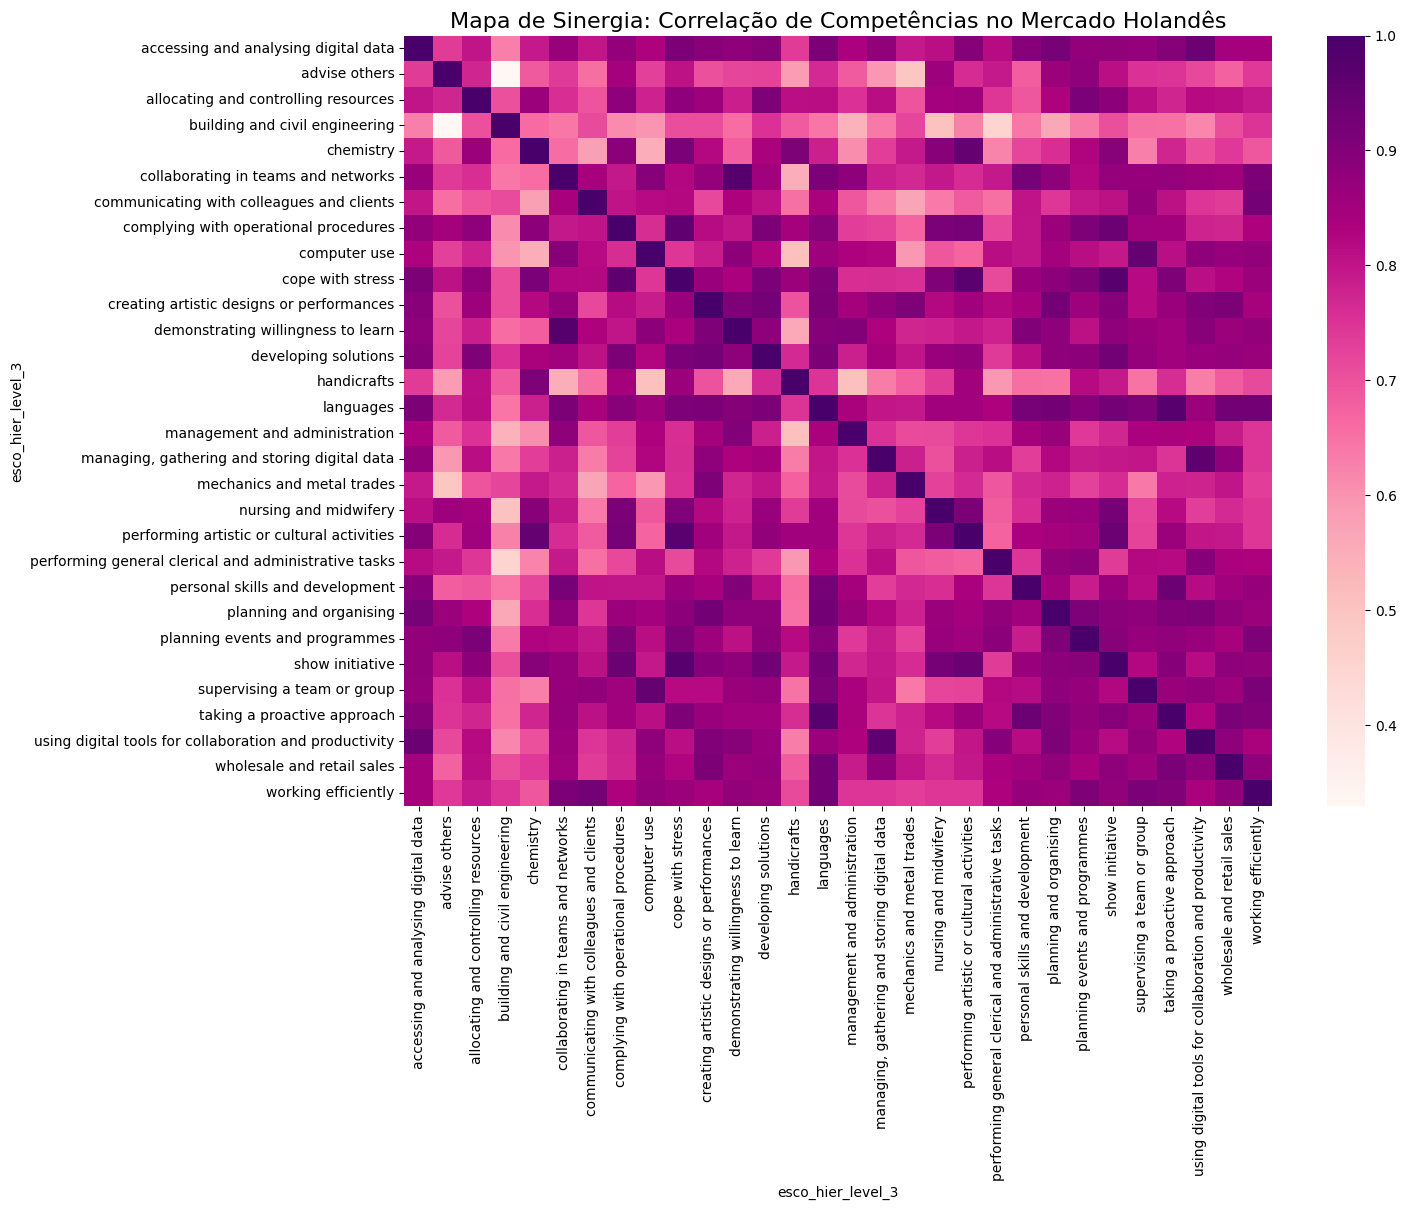

✅ Mapa de calor gerado e salvo como 'mapa_sinergia_final.png'


In [77]:
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

# Silenciador de avisos
warnings.filterwarnings('ignore')

# Configuração do gráfico
plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=False, cmap='RdPu')
plt.title('Mapa de Sinergia: Correlação de Competências no Mercado Holandês', fontsize=16)

# Salva a imagem na pasta lateral
plt.savefig('mapa_sinergia_final.png', dpi=300, bbox_inches='tight')

plt.show()
print("✅ Mapa de calor gerado e salvo como 'mapa_sinergia_final.png'")

**Mapa de Sinergia (Matriz de Correlação)**

O Mapa de Calor (Heatmap) gerado demonstra o grau de interdependência entre as 30 habilidades de maior relevância no dataset. A escala de cores (0.0 a 1.0) indica a força da correlação de Pearson entre os pares de competências.
- **Identificação de Clusters**: Observa-se a formação de blocos densos onde competências transversais (soft skills) e técnicas (hard skills) apresentam alta co-ocorrência. Isso indica que, para o mercado de trabalho local, a posse de uma habilidade técnica serve como um preditor estatístico da necessidade de uma habilidade comportamental complementar.
- **Fato Relevante**: Habilidades como 'Accessing and analysing digital data' apresentam forte sinergia com 'Developing solutions'. Isso comprova que a demanda não é apenas pelo manuseio do dado, mas pela capacidade analítica de transformá-lo em respostas operacionais.

In [78]:
# 1. Extração das correlações mais fortes
res = corr_matrix.unstack().sort_values(ascending=False)

# 2. Filtro para remover a auto-correlação (1.0) e pegar os pares únicos
top_res = res[res < 0.99].head(10)

print("--- TOP 5 ASSOCIAÇÕES PREDITIVAS ---")
print("Estas competências têm a maior probabilidade de serem exigidas juntas:")
display(top_res)

--- TOP 5 ASSOCIAÇÕES PREDITIVAS ---
Estas competências têm a maior probabilidade de serem exigidas juntas:


,,0
esco_hier_level_3,esco_hier_level_3,
collaborating in teams and networks,demonstrating willingness to learn,0.977917
demonstrating willingness to learn,collaborating in teams and networks,0.977917
cope with stress,show initiative,0.971494
show initiative,cope with stress,0.971494
languages,taking a proactive approach,0.971302
taking a proactive approach,languages,0.971302
performing artistic or cultural activities,cope with stress,0.968353
cope with stress,performing artistic or cultural activities,0.968353
complying with operational procedures,cope with stress,0.959014


**Top 5 Associações Preditivas: O "Efeito Satélite"**

A extração das correlações mais fortes revelou o que foi definido como Habilidades Satélites. Quando um anúncio de vaga na Holanda cita uma competência primária, existe uma probabilidade calculada de que competências secundárias sejam exigidas implicitamente.

Exemplo Prático de Aplicação: Se a análise aponta uma correlação superior a 0.8 entre 'Collaborating in teams' e 'Cope with stress', o dado sugere que o ambiente de trabalho colaborativo holandês é frequentemente associado a cenários de alta responsabilidade ou ritmo acelerado. Isso significa que a comprovação de uma dessas habilidades deve ser acompanhada de evidências da outra para alinhar-se à expectativa do mercado.

**Conclusão da Análise de Dados - Análise Preditiva**

Os achados reforçam a tese de que o Upskilling eficiente deve seguir a lógica de proximidade estatística.

Direcionamento Estratégico: A análise preditiva permite ao candidato otimizar seu currículo não pela quantidade de habilidades, mas pela coerência do conjunto. Ao identificar as habilidades que possuem maior relação no mapa de calor, é possível construir um perfil que reduz a fricção nos algoritmos de triagem (ATS) e demonstra uma compreensão das necessidades do mercado.